# Optimal Model

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import math

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from mlxtend.evaluate import GroupTimeSeriesSplit
from mlxtend.evaluate.time_series import plot_splits
from sklearn.metrics import mean_squared_error, r2_score

import keras

import tensorflow as tf
from tensorflow.keras.layers import MaxPooling1D
import datetime

%load_ext tensorboard


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [2]:
def set_reproducible(seed=12345):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

In [3]:
dps1200 = pd.read_csv("dps1200.csv")
dps1200 = dps1200.sort_values("year", ascending=True)
dps1200.head()

,year,tree,Origin,type,X2970,X2968,X2966,X2964,X2962,X2960,...,X818,X816,X814,X812,X810,X808,X806,X804,X802,X800
408,1194,Bre082,NOR,water,0.017617,0.017783,0.017949,0.018133,0.018348,0.018584,...,-0.019568,-0.019358,-0.019162,-0.018992,-0.018855,-0.018760,-0.018710,-0.018708,-0.018751,-0.018827
1016,1202,Sle074,NOR,dry,0.022443,0.022758,0.023074,0.023408,0.023755,0.024105,...,-0.023845,-0.023755,-0.023694,-0.023661,-0.023658,-0.023692,-0.023765,-0.023878,-0.024026,-0.024203
409,1206,Bre082,NOR,water,0.016759,0.016905,0.017066,0.017259,0.017477,0.017703,...,-0.019145,-0.018927,-0.018732,-0.018562,-0.018425,-0.018331,-0.018287,-0.018293,-0.018340,-0.018420
1017,1211,Sle074,NOR,dry,0.021679,0.022010,0.022333,0.022669,0.023019,0.023379,...,-0.022540,-0.022422,-0.022334,-0.022283,-0.022271,-0.022302,-0.022381,-0.022508,-0.022674,-0.022868
410,1216,Bre082,NOR,water,0.017110,0.017286,0.017470,0.017686,0.017928,0.018177,...,-0.019800,-0.019588,-0.019402,-0.019246,-0.019122,-0.019033,-0.018987,-0.018990,-0.019036,-0.019116


In [4]:
features = dps1200.iloc[:, 4:].values
labels = dps1200.iloc[:, 0].values

In [5]:
def convertToDecade(y:int) -> int: 
    return int(str(y)[:3])

def calculate_sample_weights(y_train):

    decades = [convertToDecade(year) for year in y_train]

    unique_decades, counts = np.unique(decades, return_counts=True)
    total_samples = len(y_train)
    
    weights = {}
    for decade, count in zip(unique_decades, counts):
        weights[decade] = 1 - count/total_samples

    sample_weights = []
    for year in y_train:
        sample_weights.append(weights[convertToDecade(year)])
        
    return np.array(sample_weights)            


First redifine the model into a function where the hyperparameters are inputs. This function evaluates the model and ouptups a desired score/metric.

In [6]:
def build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim):

    activation1='relu'
    activation2='linear'
    
    model = keras.Sequential()
    model.add(keras.layers.Input((input_dim, 1)))
    model.add(keras.layers.GaussianNoise(0.0001))

    model.add(keras.layers.Conv1D(C1_K, (C1_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C2_K, (C2_S), padding='valid', activation=activation1))
    model.add(keras.layers.Conv1D(C3_K, (C3_S), padding='valid', activation=activation1))
    model.add(MaxPooling1D(pool_size=2))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dropout(DropoutR))
    
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(DenseN, activation=activation1))
    model.add(keras.layers.Dense(1, activation=activation2))

    model.compile(loss=tf.keras.losses.Huber(), optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics=['mean_absolute_error'])
    
    return model


# Crossvalidation

Since NN training involves random sampling and weights initialization (in this case), it is usefull to use cross-validation.

In [7]:
## Compute error metrics
def error_metrices(y_true_train, y_predicted_train, y_true_test, y_predicted_test):
    rmse_train = np.sqrt(mean_squared_error(y_true_train, y_predicted_train))
    rmse_test = np.sqrt(mean_squared_error(y_true_test, y_predicted_test))
    R2_train= r2_score(y_true_train, y_predicted_train)
    R2_test= r2_score(y_true_test, y_predicted_test)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true_train, y_predicted_train).numpy()
    hub_test = h(y_true_test, y_predicted_test).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    (Train/Test) = {R2_train:.3f} / {R2_test:.3f}")
    print(f"RMSE  (Train/Test) = {rmse_train:.3f} / {rmse_test:.3f}")
    print(f"Huber (Train/Test) = {hub_train:.3f} / {hub_test:.3f}")

    return (rmse_train, rmse_test, R2_train, R2_test, hub_train, hub_test)

class ModelWithData:
    def __init__(self, history, train_x, train_label, train_predicted, test_x, test_label, test_predicted, score:float, iteration, model) -> None:
        self.history = history
        self.train_x = train_x
        self.train_label = train_label
        self.train_predicted = train_predicted
        self.test_x = test_x
        self.test_label = test_label
        self.test_predicted = test_predicted
        self.score = score
        self.iteration = iteration
        self.model = model

    def isBetter(self, otherScore: float) -> bool:
        return otherScore < 0 or (self.score >= 0 and self.score <= otherScore)

In [8]:
def calculate_groups(years, years_in_group=100):
    groups = np.zeros(len(years))

    for i in range(len(years)):
        groups[i] = years[i] // years_in_group
    
    print("Groups:")
    print(groups)
    return groups

In [13]:
class HarmonizedTimeSplit:
    def __init__(self, validation_portion=0.1, random_seed=12345):
        self._validation_portion = validation_portion
        self._random_seed = random_seed
        self._random = random.Random(random_seed)

    def split(self, X, y = None, groups = None):

        if groups is None:
            raise ValueError("The groups should be specified")
        
        self._random = random.Random(self._random_seed)
        group_dict = self._calculate_group_indices(groups)
        train_indices = []
        test_indices = []

        for group_start, group_end in group_dict.values():
            group_indices = []

            for index in range(group_start, group_end):
                group_indices.append(index)
            
            self._random.shuffle(group_indices)

            validation_end = math.floor(len(group_indices)*self._validation_portion)

            if validation_end <= 0:
                train_indices.extend(group_indices)
            else:
                test_indices.extend(group_indices[:validation_end])
                train_indices.extend(group_indices[validation_end:])

        yield np.asarray(sorted(train_indices)), np.asarray(sorted(test_indices))

        
    def _calculate_group_indices(self, groups) -> dict[str, tuple[int,int]]:
        group_dict = {}
        current_group = None

        for index in range(len(groups)):
            group = str(groups[index])

            if group in group_dict:
                if group != current_group:
                    raise ValueError(f"The groups should be specified in consequtive order. Found group '{group}' again at index {index}")
            else:
                if current_group is not None:
                    (current_group_start, current_group_end) = group_dict[current_group]
                    group_dict[current_group] = (current_group_start, index)
                
                current_group = group
                group_dict[group] = (index, len(groups))

        return group_dict

    def plot_splits(self, groups):
        for train_indices, test_indices in self.split(None, None, groups):
            self._plot_split(train_indices, test_indices, groups)
    
    def _plot_split(self, train_indices, test_indices, groups):
        group_dict = self._calculate_group_indices(groups)

        train_in_group = np.zeros(len(group_dict))
        test_in_group = np.zeros(len(group_dict))
        groups = sorted(group_dict.keys())

        for group_index, group_name in enumerate(groups):
            (group_start, group_end) = group_dict[group_name]
            train_in_group[group_index] = self._count_in_group(train_indices, group_start, group_end)
            test_in_group[group_index] = self._count_in_group(test_indices, group_start, group_end)

        x_values = np.arange(len(groups))
        width = 0.33

        rects = plt.bar(x_values, train_in_group, width, color='k', label='Train')
        plt.bar_label(rects, padding=3)
        rects = plt.bar(x_values + width, test_in_group, width, color='r', label='Test')
        plt.bar_label(rects, padding=3)

        # Labels, legend, and title
        plt.xlabel('Groups')
        plt.xticks(x_values + width/2, groups)
        plt.ylabel('Sample Count')
        plt.legend()
        plt.title('Distribution of Train vs Test in Split')

        # Show the plot
        plt.show()
    
    def _count_in_group(self, indices, group_start, group_end):
        count = 0
        for train_index in indices:
            if train_index >= group_start and train_index < group_end:
                count += 1
            elif train_index >= group_end:
                break

        return count


Groups:
[11. 12. 12. ... 20. 20. 20.]


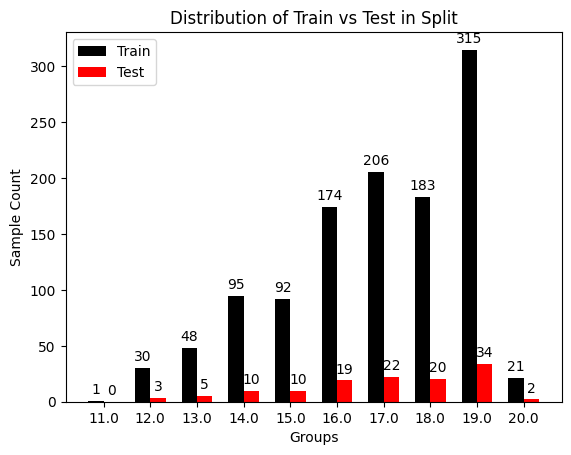

In [14]:
hts = HarmonizedTimeSplit(validation_portion=0.1)
y = np.array(labels)
groups = calculate_groups(y, 100)
hts.plot_splits(groups)

In [15]:

def evaluations_of_models(features, labels, DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, seed=12345, name="Anabell", epochs=100, years_in_group=100, validation_portion=0.01):    

    x = np.array(features)
    y = np.array(labels)
    groups = calculate_groups(y, years_in_group)
    input_dim = 410
    
    # generate model
    model = build_model(DenseN, DropoutR, C1_K, C1_S, C2_K, C2_S, C3_K, C3_S, input_dim)

    # Define the number of folds for Cross-Validation
    hts = HarmonizedTimeSplit(validation_portion=validation_portion)
    hts.plot_splits(groups)

    scores_train = { "rmse": [], "r2": [], "huber": []}
    scores_test = { "rmse": [], "r2": [], "huber": []}


    #monitor = EarlyStopping(monitor='val_loss', min_delta=4e-5, patience=50, verbose=0, mode='auto', restore_best_weights=True)
    #rdlr = ReduceLROnPlateau(patience=25, factor=0.5, min_lr=1e-6, monitor='val_loss', verbose=1)

    bestMwd = ModelWithData(None, 0, 0, 0, 0, 0, 0, -1, 0, None)

    tensorboard_base_dir = "tensorboard_logs"
    time_string = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    all_mwds = []
    
    # Iterate through the models
    i = 0
    for train_index, test_index in hts.split(x, y, groups):
        set_reproducible(seed)
        i = i + 1
        print(f'\n\n> Fold {i}')

        tensorboard_log_dir = f"{tensorboard_base_dir}/{name}/{time_string}/{seed}/fold_{i}"
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=tensorboard_log_dir)

        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Training the CNN-Model on X_train_fold, y_train_fold

        sample_weight=calculate_sample_weights(y_train)
        history = model.fit(x_train, y_train,
                            epochs=epochs, batch_size=45,
                            validation_data=(x_test, y_test),
                            verbose=0,
                            callbacks=[tensorboard_callback],
                            sample_weight=sample_weight)

        # Evaluation of the model on X_test_fold, y_test_fold
        evaluation_results = model.evaluate(x_test, y_test, verbose=0)
        evaluation_labels = model.metrics_names

        for j in range(len(evaluation_results)):
            print(f'{evaluation_labels[j]}: {evaluation_results[j]}')

        # Analyse error metrics

        train_pred = model.predict(x_train, verbose=0)
        test_pred = model.predict(x_test, verbose=0)

        (rmse_train, rmse_test, r2_train, r2_test, huber_train, huber_test) = error_metrices(y_train, train_pred, y_test, test_pred)

        mwd = ModelWithData(history, x_train, y_train, train_pred, x_test, y_test, test_pred, rmse_train, i, model)

        all_mwds.append(mwd)

        if mwd.isBetter(bestMwd.score):
            bestMwd = mwd

        scores_train["rmse"].append(rmse_train)
        scores_train["r2"].append(r2_train)
        scores_train["huber"].append(huber_train)

        scores_test["rmse"].append(rmse_test)
        scores_test["r2"].append(r2_test)
        scores_test["huber"].append(huber_test)

    ## clear session 
    tf.keras.backend.clear_session()

    scores_train_mean = {}
    scores_test_mean = {}
    num_model = len(scores_train["rmse"])

    for metric in scores_train.keys():
        scores_train_mean[metric] = np.mean(scores_train[metric])
        scores_test_mean[metric] = np.mean(scores_test[metric])
        print(f'Train: {metric} (mean of {num_model} models)= {scores_train_mean[metric]} \nTest: {metric} (mean of {num_model} models)= {scores_test_mean[metric]}')

    return (bestMwd, all_mwds)

Using seed 3173
Groups:
[11. 12. 12. ... 20. 20. 20.]


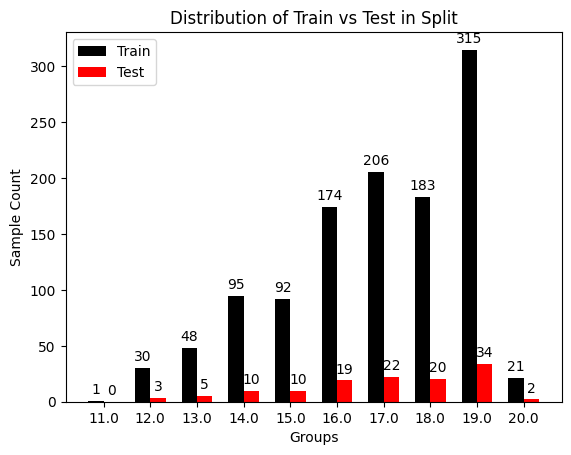



> Fold 1
loss: 69.5347900390625
compile_metrics: 70.6393051147461
*********** Benchmark results ***********

R2    (Train/Test) = 0.758 / 0.771
RMSE  (Train/Test) = 96.668 / 92.543
Huber (Train/Test) = 68.310 / 70.140
Train: rmse (mean of 1 models)= 96.66844884025643 
Test: rmse (mean of 1 models)= 92.54320939266803
Train: r2 (mean of 1 models)= 0.7583176654168656 
Test: r2 (mean of 1 models)= 0.771458062910777
Train: huber (mean of 1 models)= 68.31021118164062 
Test: huber (mean of 1 models)= 70.13984680175781
Using seed 6113
Groups:
[11. 12. 12. ... 20. 20. 20.]


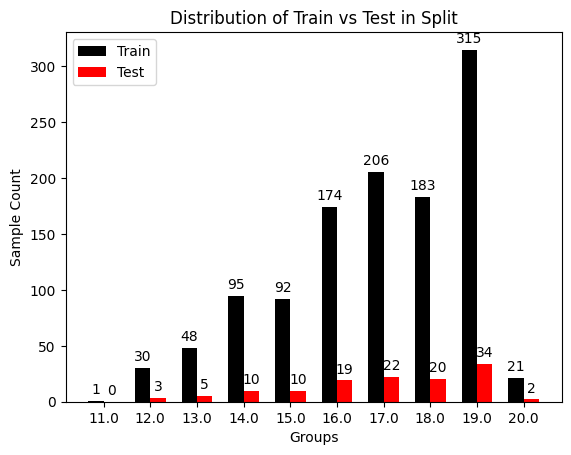



> Fold 1
loss: 68.94085693359375
compile_metrics: 70.10086059570312
*********** Benchmark results ***********

R2    (Train/Test) = 0.734 / 0.756
RMSE  (Train/Test) = 101.390 / 95.585
Huber (Train/Test) = 72.864 / 69.601
Train: rmse (mean of 1 models)= 101.38975912151416 
Test: rmse (mean of 1 models)= 95.58497572049818
Train: r2 (mean of 1 models)= 0.7341335172010395 
Test: r2 (mean of 1 models)= 0.7561874487371912
Train: huber (mean of 1 models)= 72.86366271972656 
Test: huber (mean of 1 models)= 69.6009292602539


In [17]:
# 3173, 6113
# Anabell: 2 Folds & 100 epochs
# Berta: 2 Folds & 500 epochs
seeds = [3173,6113]
all_mwds = []

for seed in seeds:
    print(f"Using seed {seed}")
    (bestMwd, all_mwds_of_run) = evaluations_of_models(features, labels, DenseN=351, DropoutR=0.0, C1_K=55, C1_S=45, C2_K=43, C2_S=36, C3_K=63, C3_S=1, seed=seed, name="Hellena", epochs=500, years_in_group=100, validation_portion=0.1)
    all_mwds.extend(all_mwds_of_run)

In [18]:
def plot_model_performance(mwd: ModelWithData):
    # Create an array of x-values ranging from the minimum to maximum of the data
    x_values = np.linspace(min(labels), max(labels), 100)

    # Plot the line of equality (y=x)
    plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

    # Scatter plot for predicted values
    plt.scatter(mwd.train_label, mwd.train_predicted, c='k', label='Train Labels')
    plt.scatter(mwd.test_label, mwd.test_predicted, c='r', label='Test Labels')

    # Labels, legend, and title
    plt.xlabel('True Labels')
    plt.ylabel('Predicted Labels')
    plt.legend()
    plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

    # Show the plot
    plt.show()

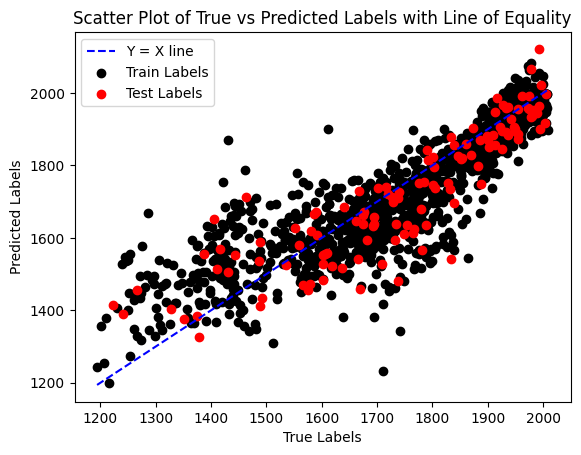

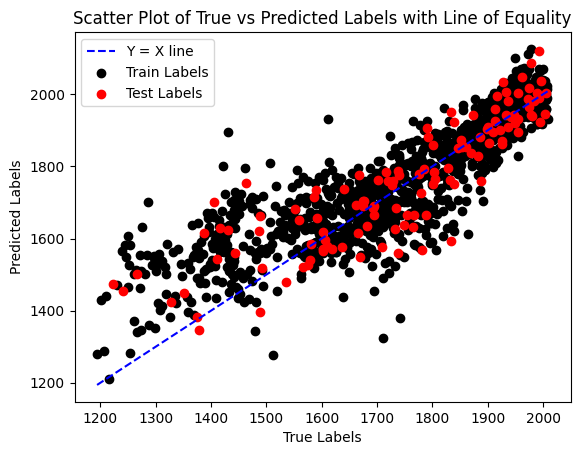

In [19]:
for mdw in all_mwds:
    plot_model_performance(mdw)

In [ ]:
%tensorboard --logdir tensorboard_logs/iteration_2

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


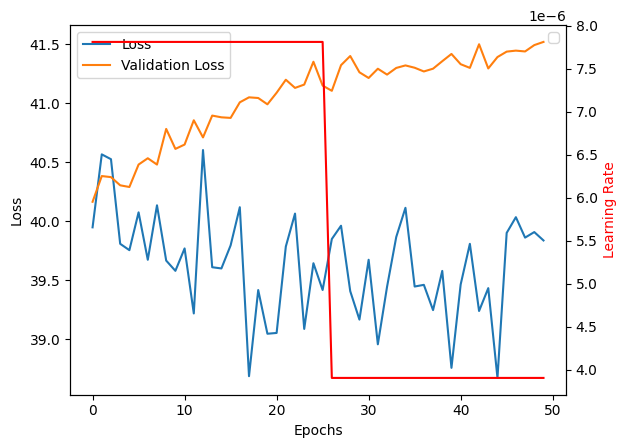

In [10]:
plt.plot(bestMwd.history.history['loss'], label='Loss')
plt.plot(bestMwd.history.history['val_loss'], label='Validation Loss')

#plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
ax2 = plt.gca().twinx()
ax2.plot(bestMwd.history.history['learning_rate'], color='r')
ax2.set_ylabel('Learning Rate',color='r')

Eval_of_model = plt.legend()

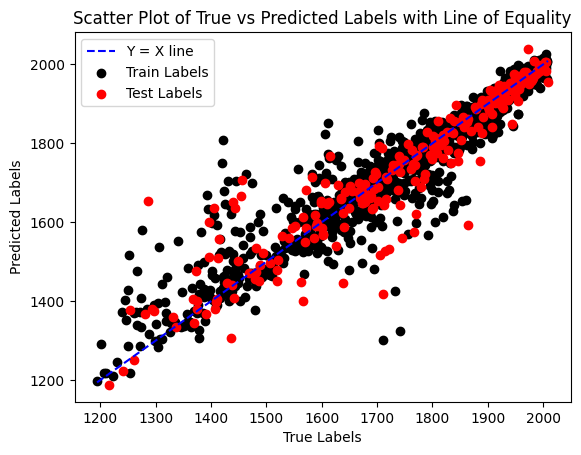

In [11]:
# Create an array of x-values ranging from the minimum to maximum of the data
x_values = np.linspace(min(labels), max(labels), 100)

# Plot the line of equality (y=x)
plt.plot(x_values, x_values, color='blue', linestyle='--', label='Y = X line')

# Scatter plot for predicted values
plt.scatter(bestMwd.train_label, bestMwd.train_predicted, c='k', label='Train Labels')
plt.scatter(bestMwd.test_label, bestMwd.test_predicted, c='r', label='Test Labels')

# Labels, legend, and title
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')
plt.legend()
plt.title('Scatter Plot of True vs Predicted Labels with Line of Equality')

# Show the plot
plt.show()

## Save the model

In [12]:
bestMwd.model.save('dps1200sub_model.keras')

# Check if working

In [13]:
dps1200sub_model = tf.keras.models.load_model('dps1200sub_model.keras')

# Show the model architecture
dps1200sub_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 410, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 366, 55)        │         2,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 331, 43)        │        85,183 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 331, 63)        │         2,772 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 165, 63)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10395)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10395)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 351)            │     3,648,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 351)            │       123,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 351)            │       123,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,960,813 (45.63 MB)

 Trainable params: 3,986,937 (15.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,973,876 (30.42 MB)

# Evaluation of the restored model

In [14]:
evaluation_results = dps1200sub_model.evaluate(features, labels, verbose=0)
evaluation_labels = dps1200sub_model.metrics_names

for j in range(len(evaluation_results)):
    print(f'{evaluation_labels[j]}: {evaluation_results[j]}')


loss: 39.094970703125
compile_metrics: 40.05874252319336


In [15]:
def error_metrices_restored_model(y_true, y_predicted):
    rmse_train = np.sqrt(mean_squared_error(y_true, y_predicted))
    R2_train= r2_score(y_true, y_predicted)
    h = tf.keras.losses.Huber()
    hub_train = h(y_true, y_predicted).numpy()
    
    print('*********** Benchmark results ***********\n')
    print(f"R2    = {R2_train:.3f}")
    print(f"RMSE  = {rmse_train:.3f}")
    print(f"Huber = {hub_train:.3f}")

In [16]:
restored_pred = dps1200sub_model.predict(features, verbose=0)

In [17]:
error_metrices_restored_model(labels, restored_pred)

*********** Benchmark results ***********

R2    = 0.885
RMSE  = 66.467
Huber = 39.563
